# 01 · Data Acquisition

Downloads the full Hacker News dataset from Google BigQuery and saves it as local Parquet files for fast querying in subsequent notebooks.

**Prerequisites:**
1. Create a GCP project at [console.cloud.google.com](https://console.cloud.google.com) and enable the BigQuery API
2. Run `gcloud auth application-default login` in your terminal
3. Copy `.env.example` to `.env` and set `GCP_PROJECT_ID`

**BigQuery free tier:** 1 TB/month of queries. This notebook uses ~10 GB.

In [1]:
import sys
sys.path.insert(0, '..')

import os
from dotenv import load_dotenv
load_dotenv('../.env')

import duckdb
import pandas as pd
from src.loader import fetch_from_bigquery, db, STORIES_PARQUET, COMMENTS_PARQUET

GCP_PROJECT = os.environ['GCP_PROJECT_ID']
print(f'Using GCP project: {GCP_PROJECT}')

Using GCP project: project-f00dc4b5-fcd8-42f6-a44


## Download from BigQuery

This takes 5–15 minutes and only needs to run once.

In [2]:
fetch_from_bigquery(GCP_PROJECT)

/Users/zascosium/Documents/github_proj_cv/hackermining/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Fetching stories (~2–5 min)...
Job ID 90b54ba3-5550-47f2-af10-68f426c3c10b successfully executed: 100%|██████████|

/Users/zascosium/Documents/github_proj_cv/hackermining/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Downloading: 100%|██████████|
Saved 5,536,693 stories → /Users/zascosium/Documents/github_proj_cv/hackermining/notebooks/../data/hn_stories.parquet
Fetching comments (~5–10 min)...
Job ID 1b7af6b7-9742-4c23-af65-d65e49849aa8 successfully executed: 100%|██████████|

/Users/zascosium/Documents/github_proj_cv/hackermining/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Downloading: 100%|██████████|
Saved 42,432,342 comments → /Users/zascosium/Documents/github_proj_cv/hackermining/notebooks/../data/hn_comments.parquet


## Profile the dataset

In [3]:
con = db()

print('=== STORIES ===')
print(con.execute('SELECT COUNT(*) AS n_stories FROM stories').df())
print(con.execute('SELECT MIN(posted_at), MAX(posted_at) FROM stories').df())
print(con.execute('SELECT COUNT(*) FROM stories WHERE url IS NOT NULL').df())
print()
print('=== COMMENTS ===')
print(con.execute('SELECT COUNT(*) AS n_comments FROM comments').df())

=== STORIES ===
   n_stories
0    5536693
             min(posted_at)            max(posted_at)
0 2006-10-09 20:21:51+02:00 2026-06-25 11:12:31+02:00
   count_star()
0       5203823

=== COMMENTS ===
   n_comments
0    42432342


In [4]:
# Score distribution sanity check
con.execute("""
    SELECT
        MIN(score)  AS min_score,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY score) AS median_score,
        AVG(score)  AS mean_score,
        MAX(score)  AS max_score
    FROM stories
""").df()

,min_score,median_score,mean_score,max_score
0,-1,2.0,14.53134,6015


In [5]:
# Stories per year
per_year = con.execute("""
    SELECT
        YEAR(posted_at) AS year,
        COUNT(*) AS n_stories,
        AVG(score) AS avg_score
    FROM stories
    GROUP BY 1
    ORDER BY 1
""").df()

display(per_year)

,year,n_stories,avg_score
0,2006,47,6.085106
1,2007,22472,5.101816
2,2008,70176,6.277745
3,2009,111120,8.785799
4,2010,179291,10.107144
5,2011,292816,9.448691
6,2012,311558,9.612833
7,2013,308371,11.388321
8,2014,291155,11.853040
9,2015,324927,11.610316


Matplotlib is building the font cache; this may take a moment.


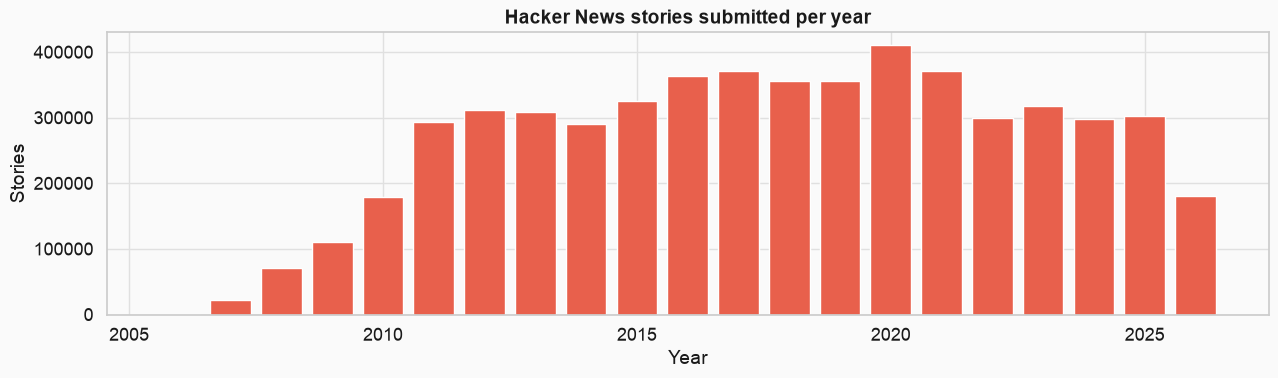

In [6]:
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
from src.viz import set_style, bar_chart

set_style()
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(per_year['year'], per_year['n_stories'], color='#e8604c', edgecolor='white')
ax.set_title('Hacker News stories submitted per year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Stories')
plt.tight_layout()
plt.savefig('../data/fig_stories_per_year.png', dpi=150, bbox_inches='tight')
plt.show()